In [ ]:
import h5py
import sys
import os
import seaborn as sns

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from typing import Iterable
import matplotlib.pyplot as plt
import torch
import numpy as np
import scipy.spatial

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# L=3x3 seeded k-mean

In [229]:
L = 3
with h5py.File(f"{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([L, L]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

1000
876


In [ ]:
def seeded_kmeans(
    X: torch.Tensor,
    k: int = 2,
    num_iters: int = 200,
    tol: float = 1e-4,
    init=None,
    prune_percentile=95,
    silhouette=-1,
):
    """
    Minimal k-means in PyTorch.
    Args
    ----
    X          : (N, D) data tensor (float32/float64) on any device
                 N = number of samples, D = number of features
    k          : number of clusters
    num_iters  : max EM iterations
    tol        : stop if centroid shift < tol         (optional)
    prune_percentile: distance-percentile to drop from *good* cluster (id 0)
    silhouette:  float, use per-point silhouette < s to prune instead, -1 to skip
    Returns
    -------
    centroids  : (k, D) tensor of final centroids
    labels     : (N,)  tensor of cluster IDs for each sample
    """
    N, D = X.shape
    # ---- 1. initial centroids --------------------------------------------
    if init is None:
        centroids = X[torch.randperm(N)[:k]]
    else:
        if isinstance(init, (np.ndarray, torch.Tensor)):
            m = init.shape[0]
        elif isinstance(init, Iterable):
            m = len(init)
            init = torch.tensor(init, dtype=X.dtype, device=X.device).reshape(m, D)
        pad = X[torch.randperm(N)[: k - m]]
        centroids = torch.vstack([init, pad]).clone()

    # ---- 2. Lloyd iterations ---------------------------------------------
    for _ in range(num_iters):
        dists = torch.cdist(X, centroids)
        labels = dists.argmin(1)
        # recompute each centroid; keep old if empty
        new_centroids = torch.stack(
            [
                (
                    X[labels == i].mean(dim=0) if (labels == i).any() else centroids[i]
                )  # avoid empty cluster crash
                for i in range(k)
            ]
        )
        # convergence test
        if torch.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    # ---- 3. outlier pruning inside *good* cluster (cluster 0) ------------
    good_mask = labels == 0
    d_good = torch.cdist(X[good_mask], centroids[0][None]).squeeze(1)

    if silhouette >= 0:  # option B: silhouette rule
        # quick 2-cluster silhouette approx
        a = d_good  # intra-cluster distances
        # inter-cluster distances
        b = torch.cdist(X[good_mask], centroids[1][None]).squeeze(1)
        s = (b - a) / torch.maximum(a, b)
        prune = s < silhouette  # border or mis-assigned
    else:  # option A: percentile rule
        thr = torch.quantile(d_good, prune_percentile / 100.0)
        prune = d_good > thr

    pruned_idx = good_mask.nonzero().squeeze(1)[prune]
    labels[pruned_idx] = -1  # mark as outlier
    return centroids, labels, pruned_idx

In [230]:
# toy blobs on GPU if available
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
X = torch.tensor(
    np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device
)

centroids, labels, pruned_idx = seeded_kmeans(X, k=2, init=(1, 0), silhouette=0.6)
print(centroids)  # centroids
print(labels[:10])  # first labels

tensor([[1.0539],
        [0.2488]], device='mps:0')
tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0], device='mps:0')


Text(0, 0.5, 'U')

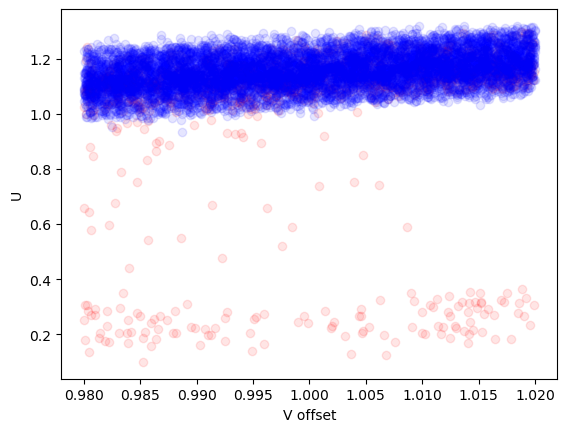

In [231]:
new_mask = torch.where(labels == 0, True, False).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

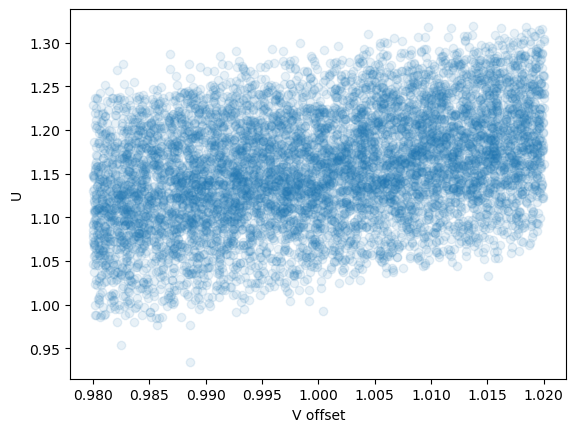

In [232]:
plt.scatter(
    dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1
)
plt.xlabel("V offset")
plt.ylabel("U")

In [233]:
np.save(f"{L}x{L}_mask.npy", new_mask)

# L=4x4 k-mean

In [207]:
L = 4
with h5py.File(f"{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([L, L]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3003
1187


In [ ]:
def kmeans(X: torch.Tensor, k: int = 2, num_iters: int = 200, tol: float = 1e-4):
    """
    Minimal k-means in PyTorch.
    Args
    ----
    X          : (N, D) data tensor (float32/float64) on any device
                 N = number of samples, D = number of features
    k          : number of clusters
    num_iters  : max EM iterations
    tol        : stop if centroid shift < tol         (optional)

    Returns
    -------
    centroids  : (k, D) tensor of final centroids
    labels     : (N,)  tensor of cluster IDs for each sample
    """
    # 1 – random initial centroids (choose k unique indices)
    perm = torch.randperm(X.size(0), device=X.device)[:k]
    centroids = X[perm]

    for _ in range(num_iters):
        # 2 – E-step: nearest-centroid assignment (Euclidean)
        dists = torch.cdist(X, centroids)  # (N,k)
        labels = dists.argmin(dim=1)

        # 3 – M-step: recompute each centroid; keep old if empty
        new_centroids = torch.stack(
            [
                (
                    X[labels == i].mean(dim=0) if (labels == i).any() else centroids[i]
                )  # avoid empty cluster crash
                for i in range(k)
            ]
        )

        # 4 – convergence test
        if torch.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    return centroids, labels

## All U_i as data

In [68]:
# toy blobs on GPU if available
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
X = torch.tensor(dat["U_i"], dtype=torch.float32, device=device)

C, y = kmeans(X, k=2)
print(C)  # centroids
print(y[:10])  # first labels

tensor([[1.1316, 1.0919, 1.0973, 1.1671, 1.0863, 0.9865, 0.9795, 1.0827, 1.1135,
         0.9664, 0.9784, 1.0803, 1.1681, 1.0892, 1.0946, 1.1646],
        [1.1104, 1.0408, 1.0710, 1.1221, 1.0587, 0.9736, 0.8988, 1.0098, 0.3084,
         1.0049, 0.9472, 0.9801, 1.0367, 1.0130, 1.0415, 1.1090]],
       device='mps:0')
tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 0], device='mps:0')


The 2 centroids are not very distinct.

Try Chebychev norm so that the centroids are more distinct?

In [69]:
def chebyshev_cdist(a, b):
    # a: (N,D), b: (M,D)  →  (N,M) matrix of ℓ∞ distances
    diff = a.unsqueeze(1) - b.unsqueeze(0)
    return diff.abs().max(dim=-1).values

def kmeans_inf(X, k, iters=100, tol=1e-4):
    centroids = X[torch.randperm(len(X))[:k]]
    for _ in range(iters):
        labels   = chebyshev_cdist(X, centroids).argmin(1)
        new_c    = torch.stack([
            X[labels==i].mean(0) if (labels==i).any() else centroids[i]
            for i in range(k)
        ])
        if (new_c-centroids).abs().max() < tol: break
        centroids = new_c
    return centroids, labels

In [77]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
X = torch.tensor(dat["U_i"], dtype=torch.float32, device=device)
centroids, labels = kmeans_inf(X, k=2)
print(centroids)  # centroids
print(labels[:10])  # first labels

tensor([[1.0329, 1.0290, 1.0429, 1.1219, 1.0383, 1.0291, 0.8598, 1.0216, 1.0180,
         1.0039, 1.0257, 1.0065, 1.1258, 1.0919, 1.0310, 1.1248],
        [1.1871, 1.1246, 1.1270, 1.1900, 1.1121, 0.9610, 1.0430, 1.1129, 1.1124,
         0.9474, 0.9489, 1.1160, 1.1835, 1.0823, 1.1276, 1.1837]],
       device='mps:0')
tensor([0, 1, 0, 0, 0, 1, 0, 0, 1, 1], device='mps:0')


Text(0, 0.5, 'U')

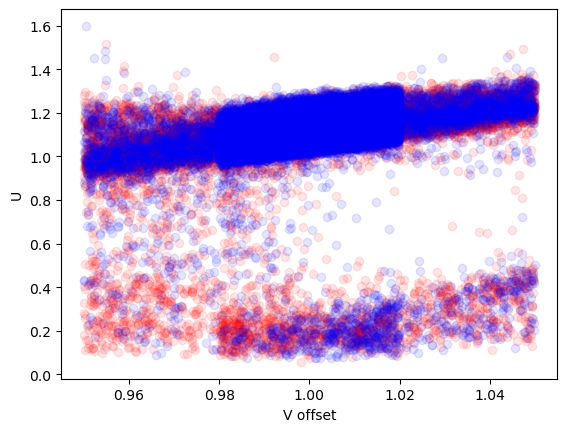

In [78]:
new_mask = torch.where(labels == 0, False, True).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

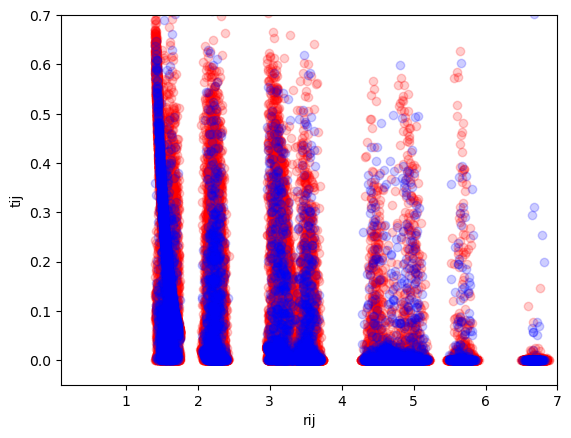

In [73]:
plt.scatter(dat["rij"][~new_mask].flatten(), dat["t_ij"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][new_mask].flatten(), dat["t_ij"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

Not effective.

## Min U_i as data

### Euclidean norm k=2 classes

In [172]:
# toy blobs on GPU if available
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
X = torch.tensor(np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device)

C, y = kmeans(X, k=2)
print(C)  # centroids
print(y[:10])  # first labels

tensor([[0.2276],
        [1.0156]], device='mps:0')
tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0], device='mps:0')


Text(0, 0.5, 'U')

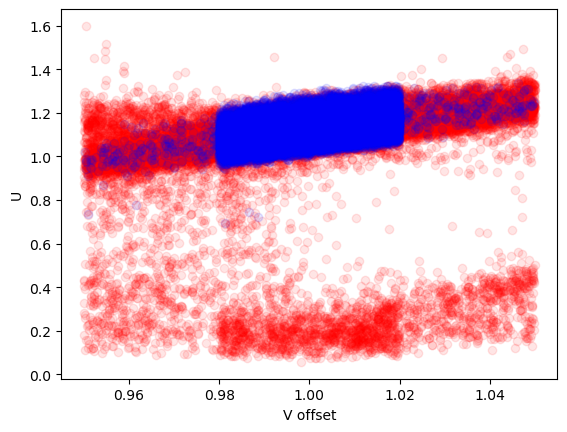

In [173]:
new_mask = torch.where(y == 0, False, True).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

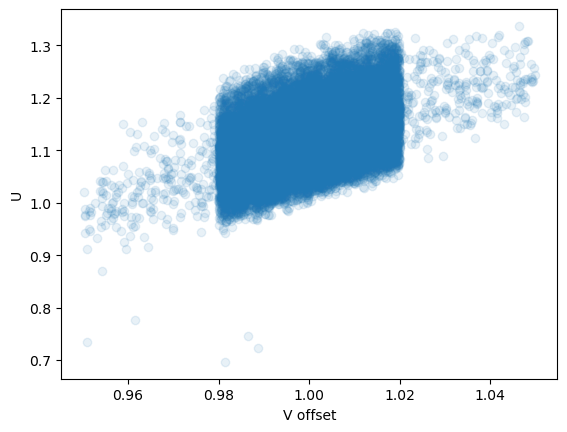

In [174]:
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

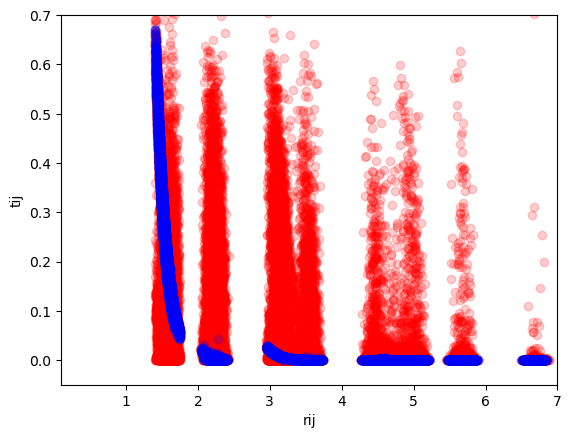

In [175]:
plt.scatter(dat["rij"][~new_mask].flatten(), dat["t_ij"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][new_mask].flatten(), dat["t_ij"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

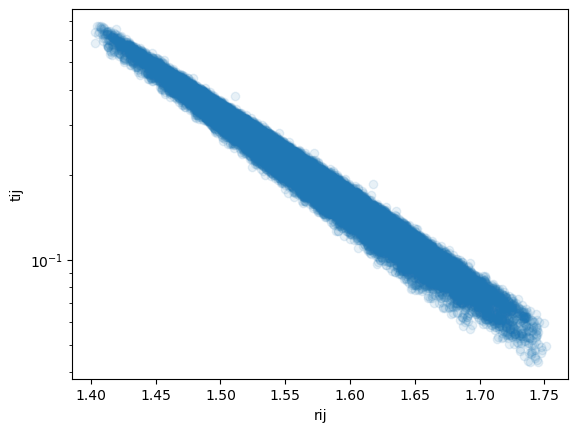

In [176]:
plt.scatter(nnr[new_mask].flatten(), nnt[new_mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

### k=3 classes (not more effective than k=2)

In [104]:
# toy blobs on GPU if available
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
X = torch.tensor(np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device)

C, y = kmeans(X, k=4)
print(C)  # centroids
print(y[:10])  # first labels

tensor([[0.2415],
        [0.1505],
        [0.3656],
        [1.0156]], device='mps:0')
tensor([2, 0, 2, 2, 0, 0, 2, 1, 3, 1], device='mps:0')


Text(0, 0.5, 'U')

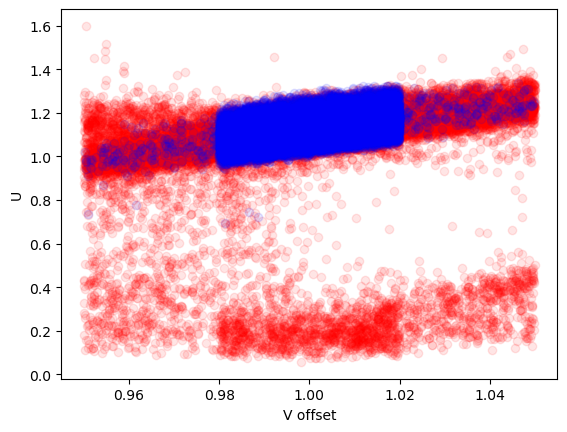

In [105]:
new_mask = torch.where(y == 3, True, False).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

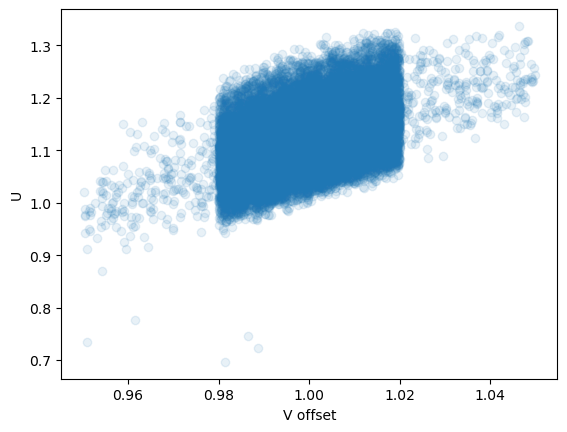

In [106]:
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

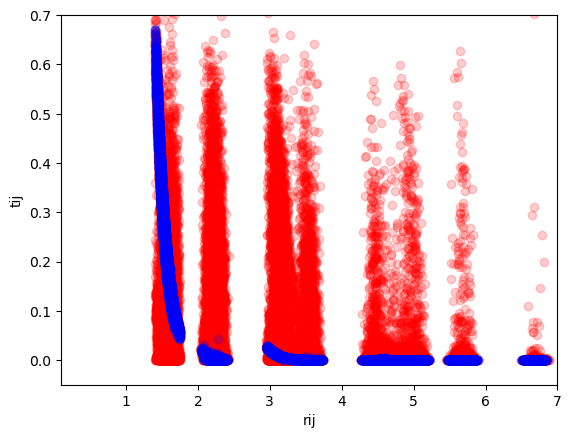

In [107]:
plt.scatter(dat["rij"][~new_mask].flatten(), dat["t_ij"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][new_mask].flatten(), dat["t_ij"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

### Chebychev norm (not very effective)

In [74]:
def chebyshev_cdist(a, b):
    # a: (N,D), b: (M,D)  →  (N,M) matrix of ℓ∞ distances
    diff = a.unsqueeze(1) - b.unsqueeze(0)
    return diff.abs().max(dim=-1).values

def kmeans_inf(X, k, iters=100, tol=1e-4):
    centroids = X[torch.randperm(len(X))[:k]]
    for _ in range(iters):
        labels   = chebyshev_cdist(X, centroids).argmin(1)
        new_c    = torch.stack([
            X[labels==i].mean(0) if (labels==i).any() else centroids[i]
            for i in range(k)
        ])
        if (new_c-centroids).abs().max() < tol: break
        centroids = new_c
    return centroids, labels

In [79]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
X = torch.tensor(
    np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device
)
centroids, labels = kmeans_inf(X, k=2)
print(centroids)  # centroids
print(labels[:10])  # first labels

tensor([[0.2276],
        [1.0156]], device='mps:0')
tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0], device='mps:0')


Text(0, 0.5, 'U')

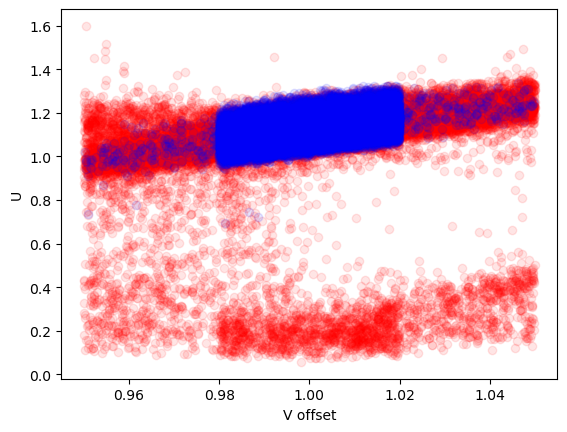

In [80]:
new_mask = torch.where(labels == 0, False, True).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

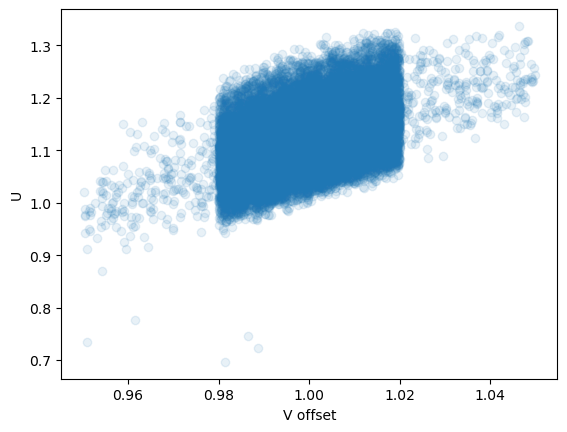

In [82]:
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

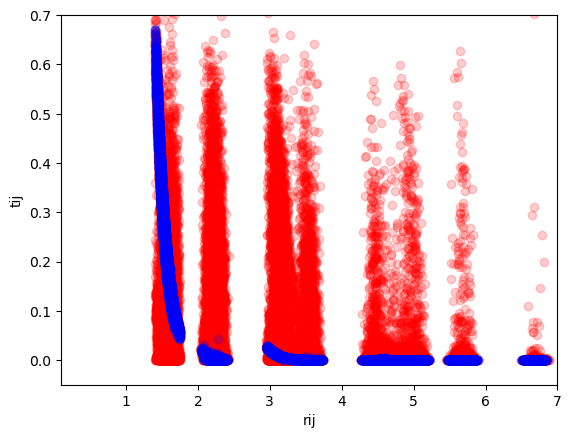

In [81]:
plt.scatter(dat["rij"][~new_mask].flatten(), dat["t_ij"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][new_mask].flatten(), dat["t_ij"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

# L=4x4 seeded k-mean (optimal)

In [221]:
L = 4
with h5py.File(f"{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([L, L]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

3003
1187


In [222]:
def seeded_kmeans(
    X: torch.Tensor,
    k: int = 2,
    num_iters: int = 200,
    tol: float = 1e-4,
    init=None,
    prune_percentile=95,
    silhouette=-1,
):
    """
    Minimal k-means in PyTorch.
    Args
    ----
    X          : (N, D) data tensor (float32/float64) on any device
                 N = number of samples, D = number of features
    k          : number of clusters
    num_iters  : max EM iterations
    tol        : stop if centroid shift < tol         (optional)
    prune_percentile: distance-percentile to drop from *good* cluster (id 0)
    silhouette:  float, use per-point silhouette < s to prune instead, -1 to skip
    Returns
    -------
    centroids  : (k, D) tensor of final centroids
    labels     : (N,)  tensor of cluster IDs for each sample
    """
    N, D = X.shape
    # ---- 1. initial centroids --------------------------------------------
    if init is None:
        centroids = X[torch.randperm(N)[:k]]
    else:
        if isinstance(init, (np.ndarray, torch.Tensor)):
            m = init.shape[0]
        elif isinstance(init, Iterable):
            m = len(init)
            init = torch.tensor(init, dtype=X.dtype, device=X.device).reshape(m, D)
        pad = X[torch.randperm(N)[: k - m]]
        centroids = torch.vstack([init, pad]).clone()

    # ---- 2. Lloyd iterations ---------------------------------------------
    for _ in range(num_iters):
        dists = torch.cdist(X, centroids)
        labels = dists.argmin(1)
        # recompute each centroid; keep old if empty
        new_centroids = torch.stack(
            [
                (
                    X[labels == i].mean(dim=0) if (labels == i).any() else centroids[i]
                )  # avoid empty cluster crash
                for i in range(k)
            ]
        )
        # convergence test
        if torch.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    # ---- 3. outlier pruning inside *good* cluster (cluster 0) ------------
    good_mask = labels == 0
    d_good = torch.cdist(X[good_mask], centroids[0][None]).squeeze(1)

    if silhouette >= 0:  # option B: silhouette rule
        # quick 2-cluster silhouette approx
        a = d_good  # intra-cluster distances
        # inter-cluster distances
        b = torch.cdist(X[good_mask], centroids[1][None]).squeeze(1)
        s = (b - a) / torch.maximum(a, b)
        prune = s < silhouette  # border or mis-assigned
    else:  # option A: percentile rule
        thr = torch.quantile(d_good, prune_percentile / 100.0)
        prune = d_good > thr

    pruned_idx = good_mask.nonzero().squeeze(1)[prune]
    labels[pruned_idx] = -1  # mark as outlier
    return centroids, labels, pruned_idx

In [223]:
# toy blobs on GPU if available
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
X = torch.tensor(
    np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device
)

centroids, labels, pruned_idx = seeded_kmeans(X, k=2, init=(1, 0), silhouette=0.6)
print(centroids)  # centroids
print(labels[:10])  # first labels

tensor([[1.0156],
        [0.2276]], device='mps:0')
tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 1], device='mps:0')


Text(0, 0.5, 'U')

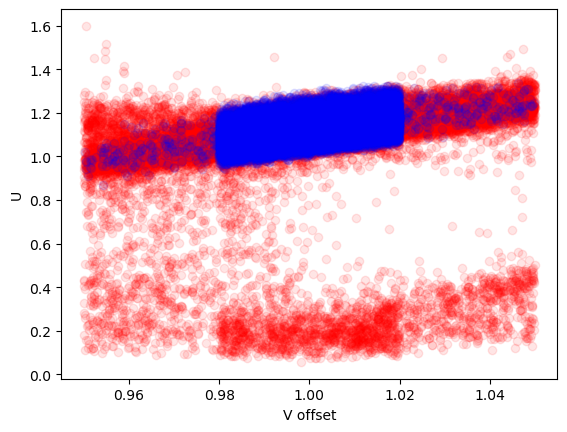

In [225]:
new_mask = torch.where(labels == 0, True, False).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

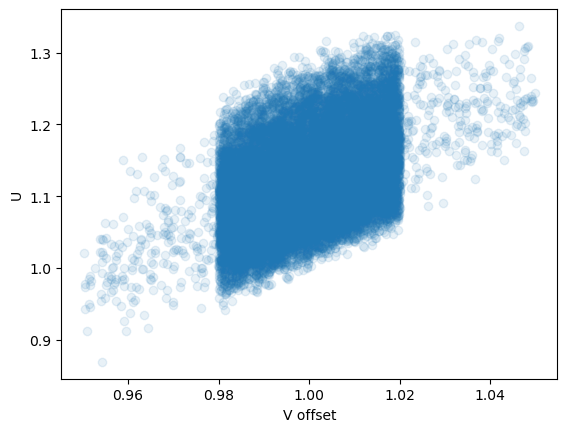

In [226]:
plt.scatter(
    dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1
)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

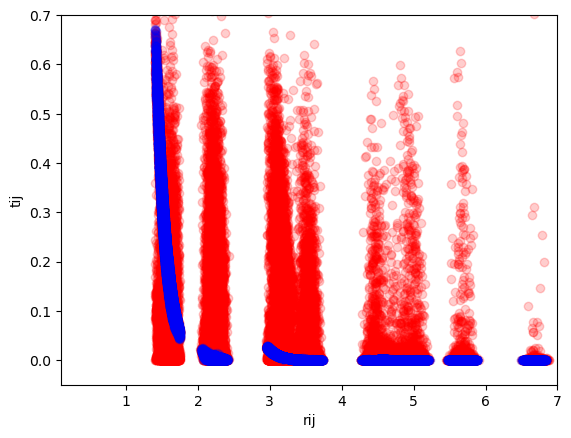

In [211]:
plt.scatter(dat["rij"][~new_mask].flatten(), dat["t_ij"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][new_mask].flatten(), dat["t_ij"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

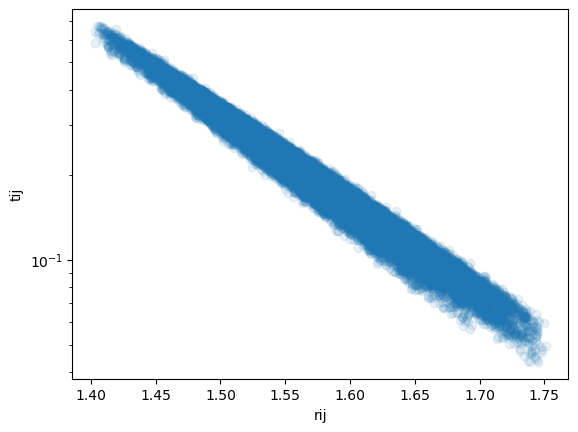

In [227]:
plt.scatter(nnr[new_mask].flatten(), nnt[new_mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

In [228]:
np.save(f"{L}x{L}_mask.npy", new_mask)

# L=4x4 k-center (not very effective)

In [83]:
def kcenter_farthest(
    X: torch.Tensor,
    k: int = 2,
    z: int = 0,
    metric: str = "euclidean",
    device: str | torch.device | None = None,
):
    """
    Greedy 2-approximate k-center clustering with optional z outliers.

    Parameters
    ----------
    X       : (N, D) float32/float64 tensor of data points.
              N = number of points, D = dimension.
    k       : desired number of centres.
    z       : number of outliers allowed (default 0 = classical k-center).
    metric  : 'euclidean'  (L2)  or 'chebyshev' (L∞ max-coord distance).
    device  : 'cpu', 'cuda', or 'mps'.  If None, choose automatically.

    Returns
    -------
    centers      : (k, D) tensor of chosen centres (order of selection).
    assignments  : (N,)   tensor of nearest-centre indices (-1 for outliers).
    radius       : float  maximum inlier distance to its centre.
    """
    if device is None:
        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available() else "cpu"
        )

    X = X.to(device)
    N, _ = X.shape
    assert k + z <= N, "k + z must not exceed number of points"

    # Helper: one-shot distance between all points and a batch of centres
    def _dist(a, b):
        if metric == "euclidean":
            # |a-b|₂  using broadcasting
            return torch.cdist(a, b)
        elif metric == "chebyshev":
            diff = a.unsqueeze(1) - b.unsqueeze(0)
            return diff.abs().amax(dim=-1)
        else:
            raise ValueError(f"Unknown metric {metric!r}")

    # --- 1. pick first centre at random
    first = torch.randint(0, N, (1,), device=device)
    centers_idx = [first.item()]
    dmin = _dist(X, X[first]).squeeze(1)  # (N,)

    # --- 2. greedy farthest-point loop
    for _ in range(1, k):
        next_idx = torch.argmax(dmin)  # farthest point
        centers_idx.append(next_idx.item())
        dmin = torch.minimum(dmin, _dist(X, X[next_idx : next_idx + 1]).squeeze(1))

    centers = X[centers_idx]  # (k,D)

    # --- 3. label each point by closest centre
    assignments = torch.argmin(_dist(X, centers), dim=1)

    # --- 4. optional z outliers: mask the z farthest points
    if z > 0:
        worst = torch.topk(dmin, z).indices
        assignments[worst] = -1  # label −1 ⇒ outlier
        inlier_mask = torch.ones(N, dtype=torch.bool, device=device)
        inlier_mask[worst] = False
        radius = dmin[inlier_mask].max().item()
    else:
        radius = dmin.max().item()

    return centers, assignments.cpu(), radius

In [ ]:
X = torch.tensor(dat["U_i"], dtype=torch.float32)
z = 100
centers, labels, R = kcenter_farthest(X, k=2, z=z)
print(f"radius after removing {z} outliers ≈ {R:.3f}")

radius after removing 100 outliers ≈ 1.378


Text(0, 0.5, 'U')

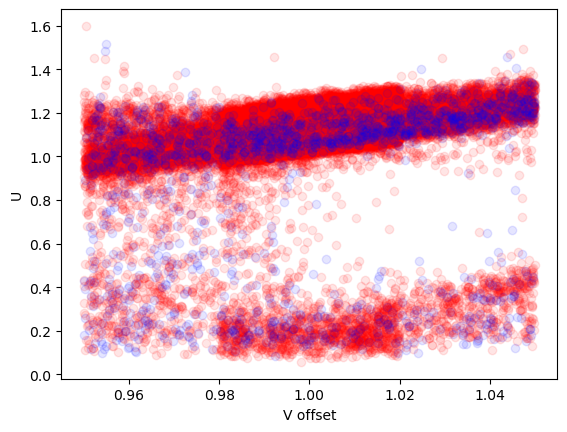

In [85]:
new_mask = torch.where(labels == 0, False, True).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

In [94]:
X = torch.tensor(np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32)
z = 10
centers, labels, R = kcenter_farthest(X, k=2, z=z)
print(f"radius after removing {z} outliers ≈ {R:.3f}")

radius after removing 10 outliers ≈ 0.319


Text(0, 0.5, 'U')

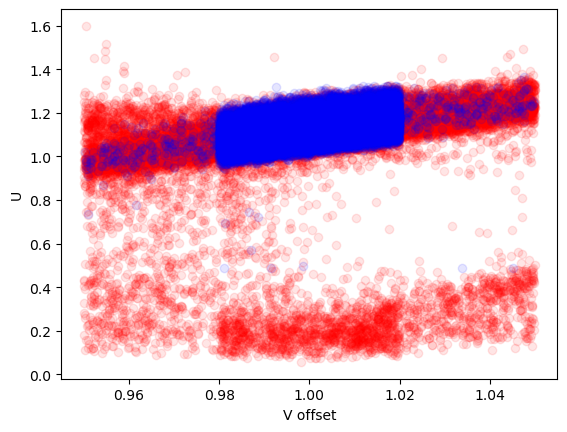

In [96]:
new_mask = torch.where(labels == 0, False, True).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

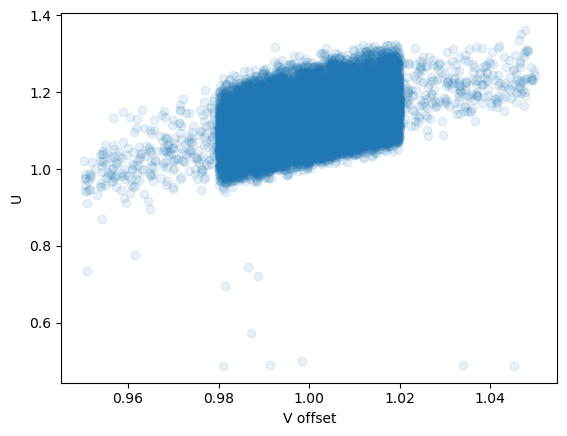

In [97]:
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

# L=4x4 one-class SVM (not very effective)

In [119]:
def ocsvm_linear(X, nu=0.1, lr=1e-2, epochs=1000):
    """
    X : (n,d) tensor on CPU / CUDA / MPS   (already standardised)
        n = number of samples, d = number of features
    ν : trade-off (0<ν≤1) — fraction of expected outliers
    returns weight w (d,), offset ρ (scalar)
    """
    n, d = X.shape
    w = torch.ones(d, device=X.device, requires_grad=True)
    rho = torch.tensor(0.8, device=X.device, requires_grad=True)
    opt = torch.optim.Adam([w, rho], lr=lr)

    for _ in range(epochs):
        opt.zero_grad()
        scores = X @ w  # w·x_i
        slack = torch.relu(rho - scores)  # ξ_i = max(0, ρ−w·x_i)
        loss = 0.5 * w.dot(w) + slack.mean() / nu - rho
        loss.backward()
        opt.step()

    return w.detach(), rho.detach()

In [128]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
# X = torch.tensor(np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device)
X = torch.tensor(np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device)
w, rho = ocsvm_linear(X, nu=0.05)


def predict(X):
    return (X.to(w.device) @ w >= rho).int()  # 1 = inlier, 0 = outlier

In [129]:
new_mask = torch.where(predict(X) == 0, False, True).detach().cpu().numpy()

Text(0, 0.5, 'U')

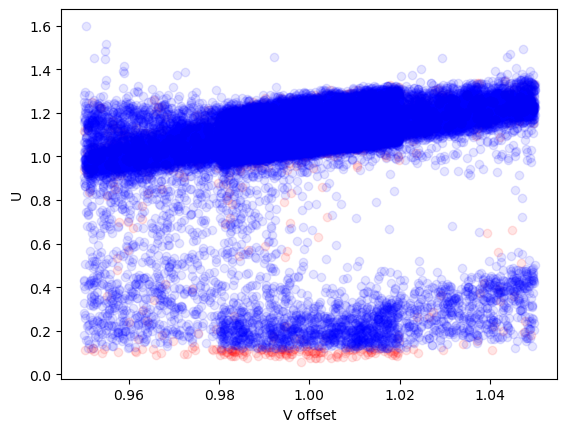

In [130]:
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

# L=5x5 seeded k-mean (optimal)

In [213]:
L = 5
with h5py.File(f"{L}x{L}_alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([L, L]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
print(len(dat["t_ij"]))
print(nmask)

1000
302


In [214]:
def seeded_kmeans(
    X: torch.Tensor,
    k: int = 2,
    num_iters: int = 200,
    tol: float = 1e-4,
    init=None,
    prune_percentile=95,
    silhouette=-1,
):
    """
    Minimal k-means in PyTorch.
    Args
    ----
    X          : (N, D) data tensor (float32/float64) on any device
                 N = number of samples, D = number of features
    k          : number of clusters
    num_iters  : max EM iterations
    tol        : stop if centroid shift < tol         (optional)
    prune_percentile: distance-percentile to drop from *good* cluster (id 0)
    silhouette:  float, use per-point silhouette < s to prune instead, -1 to skip
    Returns
    -------
    centroids  : (k, D) tensor of final centroids
    labels     : (N,)  tensor of cluster IDs for each sample
    """
    N, D = X.shape
    # ---- 1. initial centroids --------------------------------------------
    if init is None:
        centroids = X[torch.randperm(N)[:k]]
    else:
        if isinstance(init, (np.ndarray, torch.Tensor)):
            m = init.shape[0]
        elif isinstance(init, Iterable):
            m = len(init)
            init = torch.tensor(init, dtype=X.dtype, device=X.device).reshape(m, D)
        pad = X[torch.randperm(N)[: k - m]]
        centroids = torch.vstack([init, pad]).clone()

    # ---- 2. Lloyd iterations ---------------------------------------------
    for _ in range(num_iters):
        dists = torch.cdist(X, centroids)
        labels = dists.argmin(1)
        # recompute each centroid; keep old if empty
        new_centroids = torch.stack(
            [
                (
                    X[labels == i].mean(dim=0) if (labels == i).any() else centroids[i]
                )  # avoid empty cluster crash
                for i in range(k)
            ]
        )
        # convergence test
        if torch.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids

    # ---- 3. outlier pruning inside *good* cluster (cluster 0) ------------
    good_mask = labels == 0
    d_good = torch.cdist(X[good_mask], centroids[0][None]).squeeze(1)

    if silhouette >= 0:  # option B: silhouette rule
        # quick 2-cluster silhouette approx
        a = d_good  # intra-cluster distances
        # inter-cluster distances
        b = torch.cdist(X[good_mask], centroids[1][None]).squeeze(1)
        s = (b - a) / torch.maximum(a, b)
        prune = s < silhouette  # border or mis-assigned
    else:  # option A: percentile rule
        thr = torch.quantile(d_good, prune_percentile / 100.0)
        prune = d_good > thr

    pruned_idx = good_mask.nonzero().squeeze(1)[prune]
    labels[pruned_idx] = -1  # mark as outlier
    return centroids, labels, pruned_idx

In [215]:
# toy blobs on GPU if available
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
X = torch.tensor(
    np.min(dat["U_i"], axis=1, keepdims=True), dtype=torch.float32, device=device
)

centroids, labels, pruned_idx = seeded_kmeans(X, k=2, init=(1, 0), silhouette=0.6)
print(centroids)  # centroids
print(labels[:10])  # first labels

tensor([[1.0001],
        [0.1703]], device='mps:0')
tensor([0, 0, 1, 1, 0, 1, 1, 0, 1, 0], device='mps:0')


Text(0, 0.5, 'U')

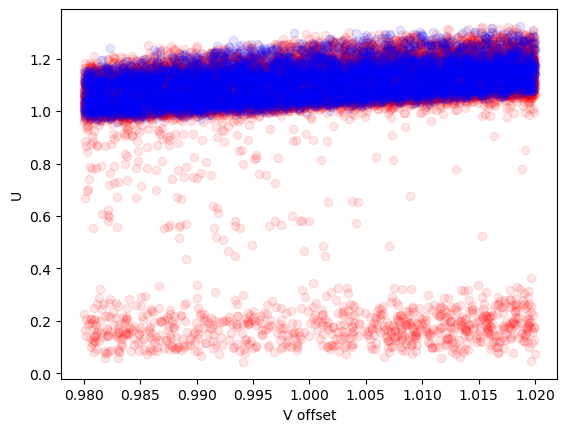

In [216]:
new_mask = torch.where(labels == 0, True, False).detach().cpu().numpy()
plt.scatter(dat["V_offset"][~new_mask].flatten(), dat["U_i"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

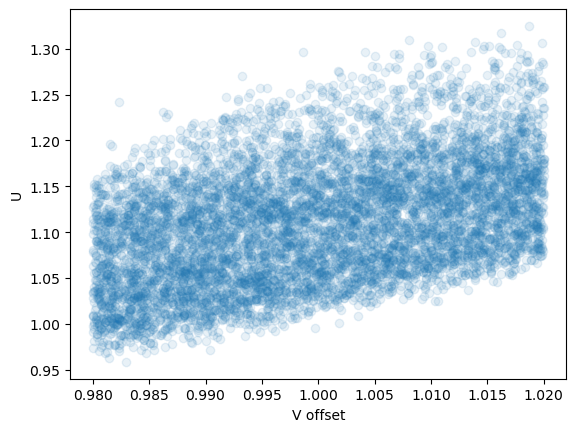

In [217]:
plt.scatter(
    dat["V_offset"][new_mask].flatten(), dat["U_i"][new_mask].flatten(), alpha=0.1
)
plt.xlabel("V offset")
plt.ylabel("U")

(-0.05, 0.7)

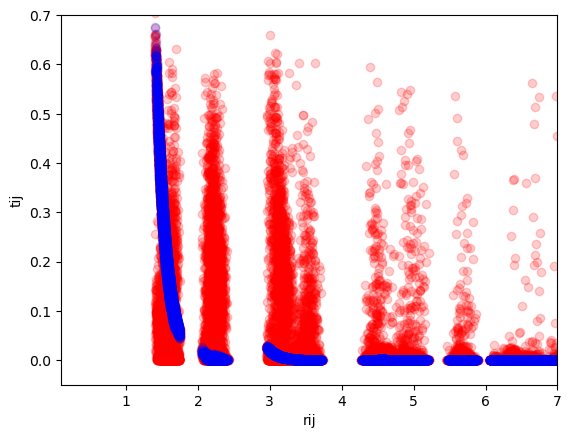

In [218]:
plt.scatter(dat["rij"][~new_mask].flatten(), dat["t_ij"][~new_mask].flatten(), color='r', alpha=0.1)
plt.scatter(dat["rij"][new_mask].flatten(), dat["t_ij"][new_mask].flatten(), color='b', alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(0.1, 7)
plt.ylim(-0.05, 0.7)

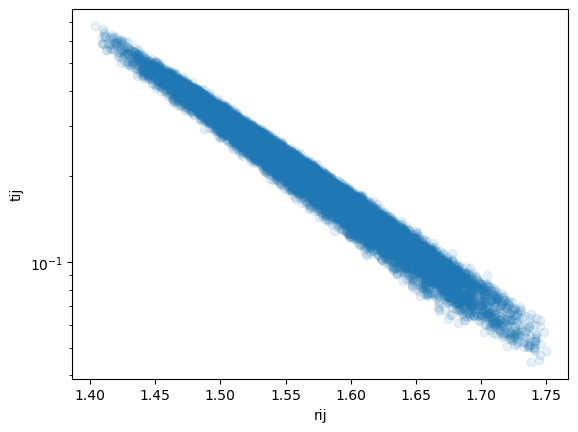

In [219]:
plt.scatter(nnr[new_mask].flatten(), nnt[new_mask].flatten(), alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.yscale("log")

In [220]:
np.save(f"{L}x{L}_mask.npy", new_mask)

# TODO: mixed L seeded k-mean with pruning